# IEEE-CIS Fraud Detection - Exploratory Data Analysis

This notebook explores the [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) datasets on the Unity Catalog Volume (`/Volumes/fraud/bronze/data/raw/`), downloaded via `scripts/download_ieee_fraud_data.py`.

**Goals:**
- Understand table structure, grain, and join relationships
- Profile the target (`isFraud`) and core transaction features
- Assess missingness and identity coverage
- Compare train vs test distributions
- Summarize implications for modeling and the fraud-scoring engine


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:

from fraud_scoring_engine.ingest.paths import ieee_data_paths

SEED = 42
SAMPLE_N = 50_000
START_DATE = pd.Timestamp("2017-11-30")

DATA_DIR = ieee_data_paths().data_dir
FILES = {
    "train_transaction": DATA_DIR / "train_transaction.csv",
    "train_identity": DATA_DIR / "train_identity.csv",
    "test_transaction": DATA_DIR / "test_transaction.csv",
    "test_identity": DATA_DIR / "test_identity.csv",
    "sample_submission": DATA_DIR / "sample_submission.csv",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("DATA_DIR:", DATA_DIR)
print("Files exist:", {k: v.exists() for k, v in FILES.items()})


DATA_DIR: c:\Repos\fraud-scoring-engine\data\raw
Files exist: {'train_transaction': True, 'train_identity': True, 'test_transaction': True, 'test_identity': True, 'sample_submission': True}


In [4]:
def file_inventory(files: dict[str, Path]) -> pd.DataFrame:
    """Summarize raw CSV files by existence, size, and row count.

    Args:
        files: Mapping of logical names to paths under the Volume ``raw/`` dir.

    Returns:
        DataFrame with columns ``file``, ``exists``, and when present
        ``size_mb`` and ``rows``.
    """
    rows = []
    for name, path in files.items():
        if not path.exists():
            rows.append({"file": name, "exists": False})
            continue
        with open(path, encoding="utf-8") as f:
            n_rows = sum(1 for _ in f) - 1
        rows.append({
            "file": name,
            "exists": True,
            "size_mb": round(path.stat().st_size / 1e6, 2),
            "rows": n_rows,
        })
    return pd.DataFrame(rows)


def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast column dtypes to reduce DataFrame memory usage.

    Converts low-cardinality object columns to category, floats to
    float32, and integers to the smallest unsigned/signed dtype that fits.

    Args:
        df: DataFrame to optimize (modified in place).

    Returns:
        The same DataFrame after dtype downcasting. Prints before/after
        memory usage in MB.
    """
    start = df.memory_usage(deep=True).sum()
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == "object":
            nunique = df[col].nunique(dropna=False)
            if nunique / max(len(df), 1) < 0.5:
                df[col] = df[col].astype("category")
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = df[col].astype("float32")
        elif pd.api.types.is_integer_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if c_min >= 0:
                if c_max < 255:
                    df[col] = df[col].astype("uint8")
                elif c_max < 65535:
                    df[col] = df[col].astype("uint16")
                elif c_max < 2_147_483_648:
                    df[col] = df[col].astype("int32")
            else:
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype("int8")
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype("int16")
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype("int32")
    end = df.memory_usage(deep=True).sum()
    print(f"Memory: {start / 1e6:.1f} MB -> {end / 1e6:.1f} MB")
    return df


def missing_summary(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    """Return columns with the highest missing-value rates.

    Args:
        df: Input DataFrame to profile.
        top_n: Maximum number of columns to include, by descending
            missing percentage.

    Returns:
        DataFrame with columns ``column`` and ``pct_missing`` (0–100).
    """
    pct = df.isna().mean().sort_values(ascending=False) * 100
    out = pct.head(top_n).reset_index()
    out.columns = ["column", "pct_missing"]
    return out


def ieee_feature_groups(columns) -> dict[str, list[str]]:
    """Group IEEE-CIS column names into semantic feature blocks.

    Args:
        columns: Iterable of column names (e.g. ``df.columns``).

    Returns:
        Dict mapping group names (``core``, ``card``, ``V``, ``id``, etc.)
        to lists of column names. Empty groups are omitted.
    """
    cols = list(columns)
    groups: dict[str, list[str]] = {
        "core": [],
        "card": [],
        "addr": [],
        "email": [],
        "C": [],
        "D": [],
        "M": [],
        "V": [],
        "id": [],
        "device": [],
        "other": [],
    }
    for c in cols:
        if c in ("TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD"):
            groups["core"].append(c)
        elif c.startswith("card"):
            groups["card"].append(c)
        elif c.startswith("addr"):
            groups["addr"].append(c)
        elif "emaildomain" in c.lower():
            groups["email"].append(c)
        elif len(c) > 1 and c[0] == "C" and c[1:].isdigit():
            groups["C"].append(c)
        elif len(c) > 1 and c[0] == "D" and c[1:].isdigit():
            groups["D"].append(c)
        elif len(c) > 1 and c[0] == "M" and c[1:].isdigit():
            groups["M"].append(c)
        elif len(c) > 1 and c[0] == "V" and c[1:].isdigit():
            groups["V"].append(c)
        elif c.startswith("id_"):
            groups["id"].append(c)
        elif c.startswith("Device"):
            groups["device"].append(c)
        else:
            groups["other"].append(c)
    return {k: v for k, v in groups.items() if v}


def group_missingness(df: pd.DataFrame, groups: dict[str, list[str]]) -> pd.DataFrame:
    """Compute average missing percentage per feature group.

    Args:
        df: DataFrame whose columns are grouped.
        groups: Output of ``ieee_feature_groups`` (name -> column list).

    Returns:
        DataFrame sorted by ``avg_pct_missing`` descending, with columns
        ``group``, ``n_columns``, and ``avg_pct_missing``.
    """
    rows = []
    for name, cols in groups.items():
        present = [c for c in cols if c in df.columns]
        if not present:
            continue
        rows.append({
            "group": name,
            "n_columns": len(present),
            "avg_pct_missing": df[present].isna().mean().mean() * 100,
        })
    return pd.DataFrame(rows).sort_values("avg_pct_missing", ascending=False)


def load_transaction(path: Path) -> pd.DataFrame:
    """Load a transaction CSV with compact dtypes and reduced memory.

    Args:
        path: Path to ``train_transaction.csv`` or ``test_transaction.csv``.

    Returns:
        Transaction DataFrame. Includes ``isFraud`` when loading train files.
    """
    dtype = {"TransactionID": "int32", "TransactionDT": "int32"}
    if "train" in path.name:
        dtype["isFraud"] = "int8"
    df = pd.read_csv(path, dtype=dtype, low_memory=False)
    return reduce_mem_usage(df)


def load_identity(path: Path) -> pd.DataFrame:
    """Load an identity CSV with compact dtypes and reduced memory.

    Args:
        path: Path to ``train_identity.csv`` or ``test_identity.csv``.

    Returns:
        Identity DataFrame keyed by ``TransactionID``.
    """
    df = pd.read_csv(path, dtype={"TransactionID": "int32"}, low_memory=False)
    return reduce_mem_usage(df)


def fraud_rate_by(series: pd.Series, target: pd.Series, top_n: int = 15) -> pd.DataFrame:
    """Rank categorical levels by fraud rate.

    Args:
        series: Categorical or object feature (e.g. ``ProductCD``).
        target: Binary ``isFraud`` labels aligned with ``series``.
        top_n: Maximum number of levels to return.

    Returns:
        DataFrame indexed by feature level with ``count`` and ``mean``
        (fraud rate). Levels with fewer than 100 observations are excluded.
    """
    tmp = pd.DataFrame({"feature": series, "isFraud": target})
    agg = tmp.groupby("feature", observed=True)["isFraud"].agg(["count", "mean"])
    agg = agg[agg["count"] >= 100].sort_values("mean", ascending=False)
    return agg.head(top_n)


## 1. Dataset inventory and schema


In [5]:
inventory = file_inventory(FILES)
display(inventory)

,file,exists,size_mb,rows
0,train_transaction,True,683.3500,590540
1,train_identity,True,26.5300,144233
2,test_transaction,True,613.1900,506691
3,test_identity,True,25.8000,141907
4,sample_submission,True,6.0800,506691


In [6]:
train_txn_preview = pd.read_csv(FILES["train_transaction"], nrows=5)
train_id_preview = pd.read_csv(FILES["train_identity"], nrows=5)
submission = pd.read_csv(FILES["sample_submission"], nrows=5)

print("train_transaction columns:", len(pd.read_csv(FILES["train_transaction"], nrows=0).columns))
print("train_identity columns:", len(pd.read_csv(FILES["train_identity"], nrows=0).columns))

train_transaction columns: 394
train_identity columns: 41


In [7]:
display(train_txn_preview.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,...,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


**`train_transaction` column reference** (394 columns). Numbered blocks share the same meaning within each prefix; the preview above truncates most `V*` columns.

- **TransactionID** — Unique row key; join key to `train_identity`
- **isFraud** — Binary target (1 = fraud); present in train only
- **TransactionDT** — Seconds elapsed since 2017-11-30 (convert to datetime for analysis)
- **TransactionAmt** — Transaction amount (USD)
- **ProductCD** — Product / payment channel code
- **card1–card6** — Anonymized payment-card attributes (issuer, region, type-style codes)
- **addr1, addr2** — Billing address region codes
- **dist1, dist2** — Distance / mismatch signals between address and other fields
- **P_emaildomain, R_emaildomain** — Purchaser vs recipient email domain
- **C1–C14** — Counting features (how often a value or entity was seen in a window)
- **D1–D15** — Timedelta features (time since a prior event for an entity)
- **M1–M9** — Match flags (whether pairs of fields agree)
- **V1–V339** — Vesta anonymized engineered features (IEEE does not document individual `V*` names; treat as one high-dimensional numeric block)

`test_transaction` uses the same columns except there is no `isFraud`.

In [8]:
display(train_id_preview.head())

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,...,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0000,70787.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,...,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0000,98945.0000,NaN,NaN,0.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,49.0000,-300.0000,...,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0000,191631.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,52.0000,NaN,...,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0000,221832.0000,NaN,NaN,0.0000,-6.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,52.0000,NaN,...,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0000,7460.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,NaN,-300.0000,...,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0000,1280x800,match_status:2,T,F,T,T,desktop,MacOS


**`train_identity` column reference** (41 columns). Optional side table left-joined on `TransactionID`; only ~24% of train transactions have an identity row (see section 6).

- **TransactionID** — Join key to `train_transaction`
- **id_01–id_38** — Anonymized identity / network / browser signals (individual `id_*` meanings are not published by IEEE)
- **DeviceType** — Device category (e.g. desktop vs mobile)
- **DeviceInfo** — Device descriptor string (high cardinality)

In [9]:
display(submission.head())

,TransactionID,isFraud
0,3663549,0.5000
1,3663550,0.5000
2,3663551,0.5000
3,3663552,0.5000
4,3663553,0.5000


## 2. Load train data and merge identity


In [10]:
print("Loading train_transaction...")
train_txn = load_transaction(FILES["train_transaction"])
print("Loading train_identity...")
train_id = load_identity(FILES["train_identity"])

groups_txn = ieee_feature_groups(train_txn.columns)
print("Feature groups (transaction):", {k: len(v) for k, v in groups_txn.items()})

train_merged = train_txn.merge(train_id, on="TransactionID", how="left", suffixes=("", "_id"))
print(f"Merged shape: {train_merged.shape}")
print(f"Memory (deep): {train_merged.memory_usage(deep=True).sum() / 1e6:.1f} MB")
train_merged.head(3)


Loading train_transaction...
Memory: 2153.4 MB -> 1261.7 MB
Loading train_identity...
Memory: 149.5 MB -> 136.3 MB
Feature groups (transaction): {'core': 5, 'card': 6, 'addr': 2, 'email': 2, 'C': 14, 'D': 15, 'M': 9, 'V': 339, 'other': 2}
Merged shape: (590540, 434)
Memory (deep): 1681.2 MB


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,...,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Target variable (`isFraud`)


**Class balance.** Bar chart of legit vs fraud transaction counts. The dataset is highly imbalanced (~3% fraud); use stratified cross-validation and metrics such as PR-AUC rather than accuracy.

isFraud
legit    569877
fraud     20663
Name: count, dtype: int64

Percent:
isFraud
legit   96.5010
fraud    3.4990
Name: proportion, dtype: float64

Imbalance ratio (legit:fraud): 27.6:1


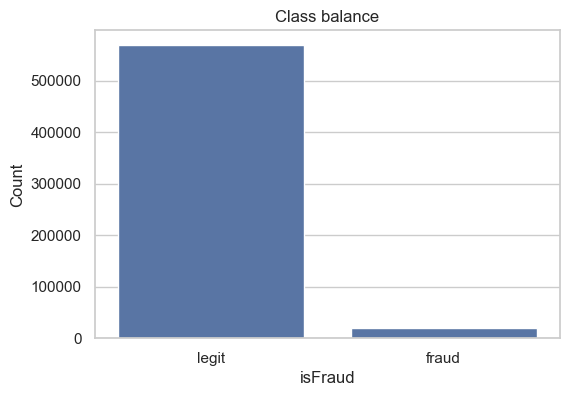

In [11]:
target_counts = train_txn["isFraud"].value_counts()
target_pct = train_txn["isFraud"].value_counts(normalize=True) * 100
print(target_counts.rename({0: "legit", 1: "fraud"}))
print("\nPercent:")
print(target_pct.rename({0: "legit", 1: "fraud"}))
imbalance = target_counts[0] / target_counts[1]
print(f"\nImbalance ratio (legit:fraud): {imbalance:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index.map({0: "legit", 1: "fraud"}), y=target_counts.values, ax=ax)
ax.set_title("Class balance")
ax.set_ylabel("Count")
plt.show()


## 4. Core transaction features


**Log transaction amount by class.** Overlapping density of `log1p(TransactionAmt)` for fraud vs legit transactions. Compare whether fraudulent purchases cluster at higher or lower amounts than legitimate ones.

Text(0.5, 1.0, 'Transaction amount by class')

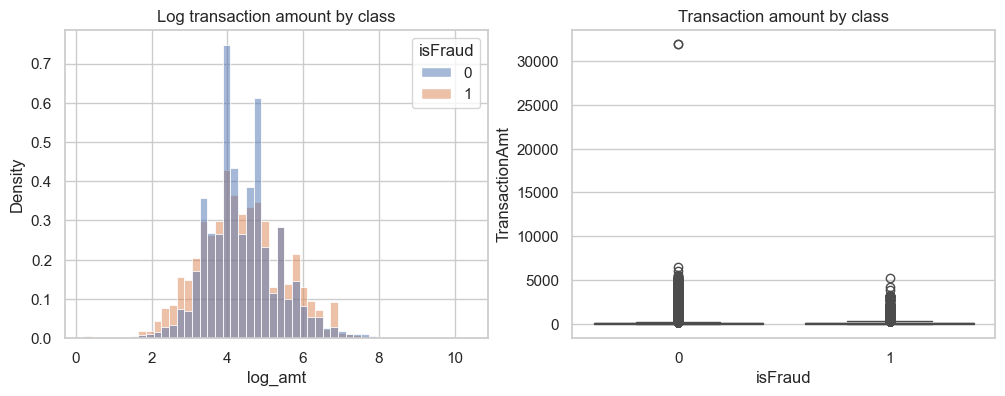

In [12]:
train_txn["txn_time"] = START_DATE + pd.to_timedelta(train_txn["TransactionDT"], unit="s")
train_txn["txn_date"] = train_txn["txn_time"].dt.floor("D")
train_txn["log_amt"] = np.log1p(train_txn["TransactionAmt"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_txn, x="log_amt", hue="isFraud", bins=50, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Log transaction amount by class")
train_txn.groupby("isFraud")["TransactionAmt"].describe()

sns.boxplot(data=train_txn, x="isFraud", y="TransactionAmt", ax=axes[1])
axes[1].set_title("Transaction amount by class")


**Fraud rate by amount decile.** Mean `isFraud` within each decile of `TransactionAmt`. Reveals non-linear risk across the amount scale and whether amount binning or caps would help modeling.

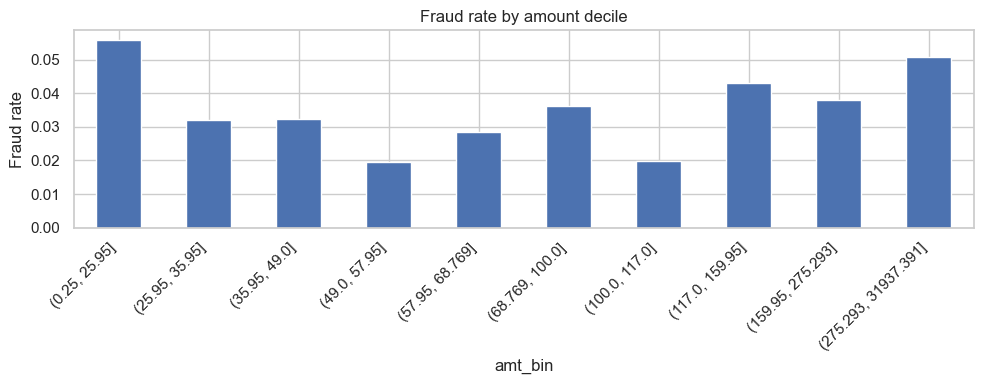

In [13]:
# Fraud rate by amount decile
train_txn["amt_bin"] = pd.qcut(train_txn["TransactionAmt"], 10, duplicates="drop")
amt_fraud = train_txn.groupby("amt_bin", observed=True)["isFraud"].mean()
amt_fraud.plot(kind="bar", figsize=(10, 4), title="Fraud rate by amount decile")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()


### Daily trends

**Daily volume and fraud rate.** Twin-axis time series: transaction count per day (blue) and mean fraud rate (coral). Look for seasonality, spikes, and temporal drift that motivate time-based validation instead of random splits.

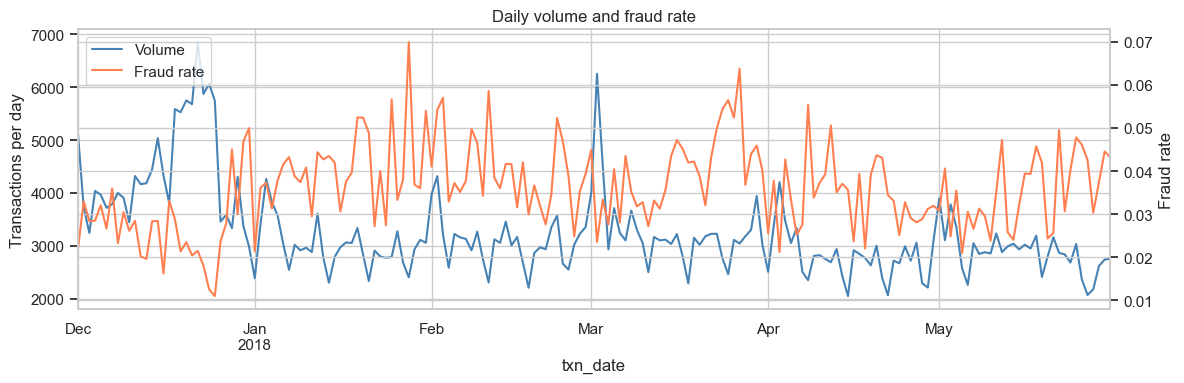

In [14]:
# Volume and fraud rate over time
daily = train_txn.groupby("txn_date").agg(volume=("TransactionID", "count"), fraud_rate=("isFraud", "mean"))
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
daily["volume"].plot(ax=ax1, color="steelblue", label="Volume")
daily["fraud_rate"].plot(ax=ax2, color="coral", label="Fraud rate")
ax1.set_ylabel("Transactions per day")
ax2.set_ylabel("Fraud rate")
ax1.set_title("Daily volume and fraud rate")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.tight_layout()
plt.show()


### Product risk

**Fraud rate by ProductCD.** Bar chart of fraud rate for product codes with at least 100 transactions. Highlights product-level risk heterogeneity and candidate categorical features for encoding.

Fraud rate by ProductCD (count >= 100):


,count,mean
feature,,
C,68519,0.1169
S,11628,0.0590
H,33024,0.0477
R,37699,0.0378
W,439670,0.0204


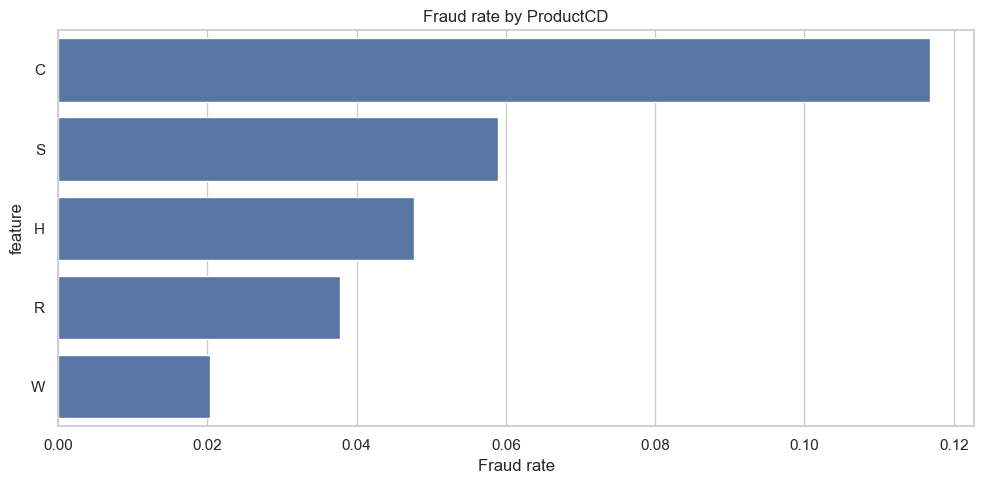

In [15]:
# ProductCD
prod = fraud_rate_by(train_txn["ProductCD"], train_txn["isFraud"], top_n=20)
print("Fraud rate by ProductCD (count >= 100):")
display(prod)
sns.barplot(data=prod.reset_index(), x="mean", y="feature")
plt.title("Fraud rate by ProductCD")
plt.xlabel("Fraud rate")
plt.tight_layout()
plt.show()

In [16]:
# Card, address, email
for col in ["card1", "card2", "addr1", "P_emaildomain", "R_emaildomain"]:
    if col not in train_txn.columns:
        continue
    print(f"\n--- {col} ---")
    print(f"Missing: {train_txn[col].isna().mean() * 100:.2f}%")
    print(f"Cardinality: {train_txn[col].nunique()}")
    display(fraud_rate_by(train_txn[col], train_txn["isFraud"], top_n=10))



--- card1 ---
Missing: 0.00%
Cardinality: 13553


,count,mean
feature,,
3643,121,0.5207
17999,101,0.4851
2939,175,0.4457
2801,411,0.3796
3702,133,0.3459
10369,162,0.3395
5009,155,0.3355
9917,919,0.3330
3867,356,0.3258



--- card2 ---
Missing: 1.51%
Cardinality: 500


,count,mean
feature,,
289.0000,118,0.4068
405.0000,228,0.4035
319.0000,100,0.3900
176.0000,513,0.3606
482.0000,168,0.3274
311.0000,289,0.2803
104.0000,754,0.2480
324.0000,331,0.2417
177.0000,1642,0.2412



--- addr1 ---
Missing: 11.13%
Cardinality: 332


,count,mean
feature,,
296.0000,367,0.2125
161.0000,421,0.1948
536.0000,309,0.1618
130.0000,342,0.0848
465.0000,503,0.0835
122.0000,1617,0.0724
308.0000,1279,0.0649
511.0000,157,0.0637
324.0000,2173,0.0515



--- P_emaildomain ---
Missing: 15.99%
Cardinality: 59


,count,mean
feature,,
mail.com,559,0.1896
outlook.es,438,0.1301
aim.com,315,0.1270
outlook.com,5096,0.0946
hotmail.es,305,0.0656
live.com.mx,749,0.0547
hotmail.com,45250,0.0530
gmail.com,228355,0.0435
yahoo.fr,143,0.0350



--- R_emaildomain ---
Missing: 76.75%
Cardinality: 60


,count,mean
feature,,
mail.com,122,0.3770
outlook.com,2507,0.1651
outlook.es,433,0.1316
icloud.com,1398,0.1288
gmail.com,57147,0.1192
hotmail.com,27509,0.0778
hotmail.es,292,0.0685
live.com.mx,754,0.0584
yahoo.com,11842,0.0515


## 5. Missing values


**Missingness by feature group.** Average percent missing per IEEE feature block (`V`, `id`, `D`, etc.) on the merged train table. Identifies which blocks need imputation, missing indicators, or dropping before modeling.

Top 30 columns by missing % (merged):


,column,pct_missing
0,id_24,99.1962
1,id_25,99.1310
2,id_07,99.1271
3,id_08,99.1271
4,id_21,99.1264
5,id_26,99.1257
6,id_27,99.1247
7,id_23,99.1247
8,id_22,99.1247
9,dist2,93.6284


,group,n_columns,avg_pct_missing
8,id,38,84.8233
9,device,2,78.0306
10,other,2,76.6404
5,D,15,58.1513
6,M,9,49.9233
3,email,2,46.3732
7,V,339,43.0385
2,addr,2,11.1264
1,card,6,0.5053
0,core,5,0.0000


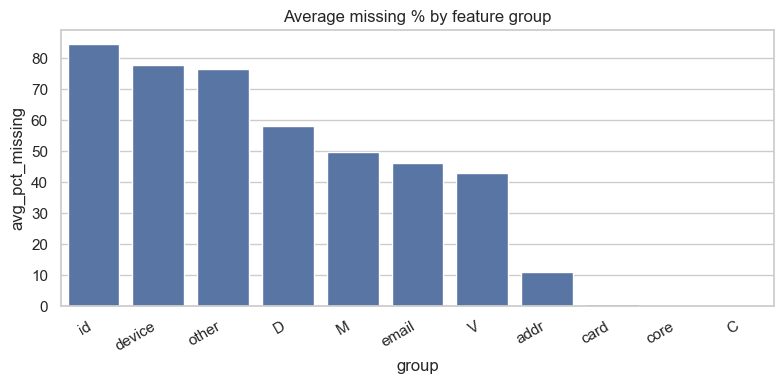

Columns with >90% missing: 12


In [17]:
groups_merged = ieee_feature_groups(train_merged.columns)
print("Top 30 columns by missing % (merged):")
display(missing_summary(train_merged, top_n=30))

gm = group_missingness(train_merged, groups_merged)
display(gm)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=gm, x="group", y="avg_pct_missing", ax=ax)
ax.set_title("Average missing % by feature group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

high_missing = (train_merged.isna().mean() > 0.9)
print(f"Columns with >90% missing: {high_missing.sum()}")


In [18]:
# Missingness before vs after identity join
id_cols = [c for c in train_merged.columns if c.startswith("id_") or c.startswith("Device")]
id_miss = train_merged[id_cols].isna().mean().mean() * 100 if id_cols else 0
print(f"Avg missing % on identity columns after left join: {id_miss:.2f}%")
display(pd.DataFrame({
    "stage": ["transaction only", "after identity join"],
    "avg_missing_all": [
        train_txn.isna().mean().mean() * 100,
        train_merged.isna().mean().mean() * 100,
    ],
}))


Avg missing % on identity columns after left join: 84.48%


,stage,avg_missing_all
0,transaction only,40.6606
1,after identity join,45.0744


## 6. Identity table and join coverage


In [19]:
has_identity = train_merged["id_01"].notna() if "id_01" in train_merged.columns else train_merged["TransactionID"].isin(train_id["TransactionID"])
coverage = has_identity.mean() * 100
print(f"Transactions with identity row: {coverage:.2f}%")

fraud_with = train_merged.loc[has_identity, "isFraud"].mean()
fraud_without = train_merged.loc[~has_identity, "isFraud"].mean()
print(f"Fraud rate with identity: {fraud_with:.4f}")
print(f"Fraud rate without identity: {fraud_without:.4f}")

for col in ["DeviceType", "DeviceInfo"]:
    if col in train_merged.columns:
        print(f"\n{col} value counts:")
        display(train_merged[col].value_counts(dropna=False).head(10))
        display(fraud_rate_by(train_merged[col], train_merged["isFraud"], top_n=10))


Transactions with identity row: 24.42%
Fraud rate with identity: 0.0785
Fraud rate without identity: 0.0209

DeviceType value counts:


DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

,count,mean
feature,,
mobile,55645,0.1017
desktop,85165,0.0652



DeviceInfo value counts:


DeviceInfo
NaN                      471874
Windows                   47722
iOS Device                19782
MacOS                     12573
Trident/7.0                7440
rv:11.0                    1901
rv:57.0                     962
SM-J700M Build/MMB29K       549
SM-G610M Build/MMB29K       461
SM-G531H Build/LMY48B       410
Name: count, dtype: int64

,count,mean
feature,,
hi6210sft Build/MRA58K,190,0.9474
SM-A300H Build/LRX22G,203,0.8325
SM-J320M Build/LMY47V,171,0.3333
WAS-LX3 Build/HUAWEIWAS-LX3,108,0.2593
Moto Z2 Play Build/NPSS26.118-19-14,129,0.2326
Moto E (4) Plus Build/NMA26.42-69,160,0.2000
SM-J701M Build/NRD90M,154,0.1948
SM-G955F Build/NRD90M,134,0.1940
Moto E (4) Build/NMA26.42-69,125,0.1840


In [20]:
id_cols = [c for c in train_merged.columns if c.startswith("id_")]
if id_cols:
    id_missing = train_merged[id_cols].isna().mean().sort_values(ascending=False).head(15)
    print("Top identity columns by missing %:")
    display(train_merged[id_cols].describe().T.head(15))


Top identity columns by missing %:


,count,mean,std,min,25%,50%,75%,max
id_01,144233.0000,-10.1705,14.3479,-100.0000,-10.0000,-5.0000,-5.0000,0.0000
id_02,140872.0000,174716.5938,159651.8125,1.0000,67992.0000,125800.5000,228749.0000,999595.0000
id_03,66324.0000,0.0602,0.5982,-13.0000,0.0000,0.0000,0.0000,10.0000
id_04,66324.0000,-0.0589,0.7010,-28.0000,0.0000,0.0000,0.0000,0.0000
id_05,136865.0000,1.6156,5.2499,-72.0000,0.0000,0.0000,1.0000,52.0000
id_06,136865.0000,-6.6987,16.4911,-100.0000,-6.0000,0.0000,0.0000,0.0000
id_07,5155.0000,13.2854,11.3842,-46.0000,5.0000,14.0000,22.0000,61.0000
id_08,5155.0000,-38.6004,26.0849,-100.0000,-48.0000,-34.0000,-23.0000,0.0000
id_09,74926.0000,0.0910,0.9838,-36.0000,0.0000,0.0000,0.0000,25.0000
id_10,74926.0000,-0.3011,2.7894,-100.0000,0.0000,0.0000,0.0000,0.0000


## 7. Anonymized feature blocks (C, D, M, V)


**Top V* features by |corr(isFraud)|.** Eight histograms of the Vesta columns with the strongest Pearson association to the label (100k-row sample). Compare shape overlap; even top univariate `V` features are often only weakly separable.

,group,n_columns,avg_pct_missing,median_pct_missing,max_pct_missing
0,C,14,0.0000,0.0000,0.0000
1,D,15,58.1513,52.4674,93.4099
2,M,9,49.9233,47.6588,59.3494
3,V,339,43.0385,47.2935,86.1237


Top 8 |corr(isFraud)| among V features (100k sample):


,abs_corr
V257,0.3656
V246,0.3468
V244,0.3444
V242,0.3417
V201,0.3129
V200,0.3005
V258,0.2967
V189,0.2958


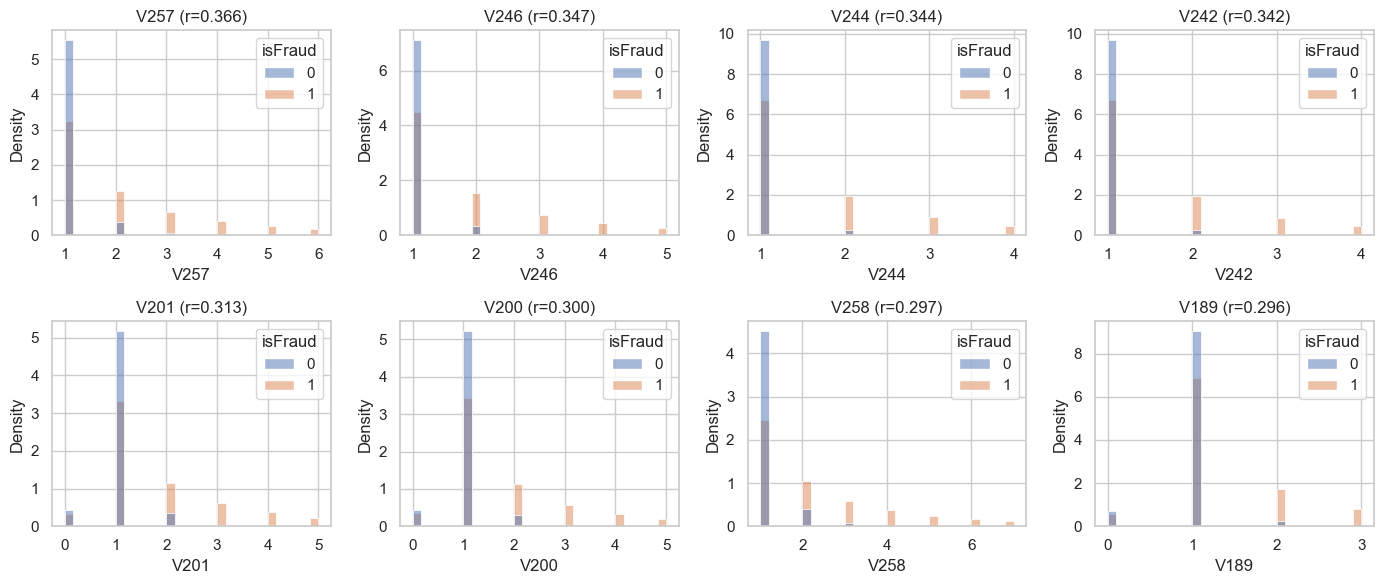

In [21]:
block_rows = []
for name in ["C", "D", "M", "V"]:
    cols = groups_txn.get(name, [])
    if not cols:
        continue
    miss = train_txn[cols].isna().mean() * 100
    block_rows.append({
        "group": name,
        "n_columns": len(cols),
        "avg_pct_missing": miss.mean(),
        "median_pct_missing": miss.median(),
        "max_pct_missing": miss.max(),
    })
display(pd.DataFrame(block_rows))

v_cols = groups_txn.get("V", [])
if v_cols:
    v_sample = train_txn[v_cols + ["isFraud"]].sample(
        n=min(100_000, len(train_txn)), random_state=SEED
    )
    v_corr = v_sample.corr(numeric_only=True)["isFraud"].drop("isFraud")
    top_v = v_corr.abs().nlargest(8).index.tolist()
    print("Top 8 |corr(isFraud)| among V features (100k sample):")
    display(v_corr.abs().loc[top_v].to_frame("abs_corr"))

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for ax, col in zip(axes.ravel(), top_v):
        lo, hi = train_txn[col].quantile([0.01, 0.99])
        if lo == hi:
            hi = lo + 1
        sns.histplot(
            data=train_txn, x=col, hue="isFraud", bins=30,
            stat="density", common_norm=False, ax=ax,
            binrange=(lo, hi),
        )
        ax.set_title(f"{col} (r={v_corr[col]:.3f})")
    plt.tight_layout()
    plt.show()


**Correlation heatmap (top 20 + target).** Pearson correlations among the 20 numeric features most correlated with `isFraud` plus the label. Individual correlations are typically weak; the heatmap shows redundancy clusters and modest linear signal.

Top 20 |correlation| with isFraud:


,abs_corr
V257,0.3656
V246,0.3468
V244,0.3444
V242,0.3417
V201,0.3129
V200,0.3005
V258,0.2967
V189,0.2958
V158,0.2946
V156,0.2898


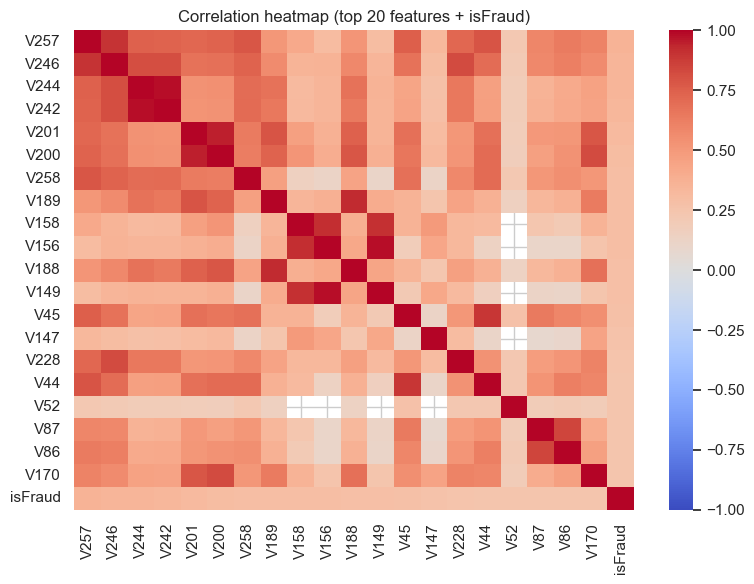

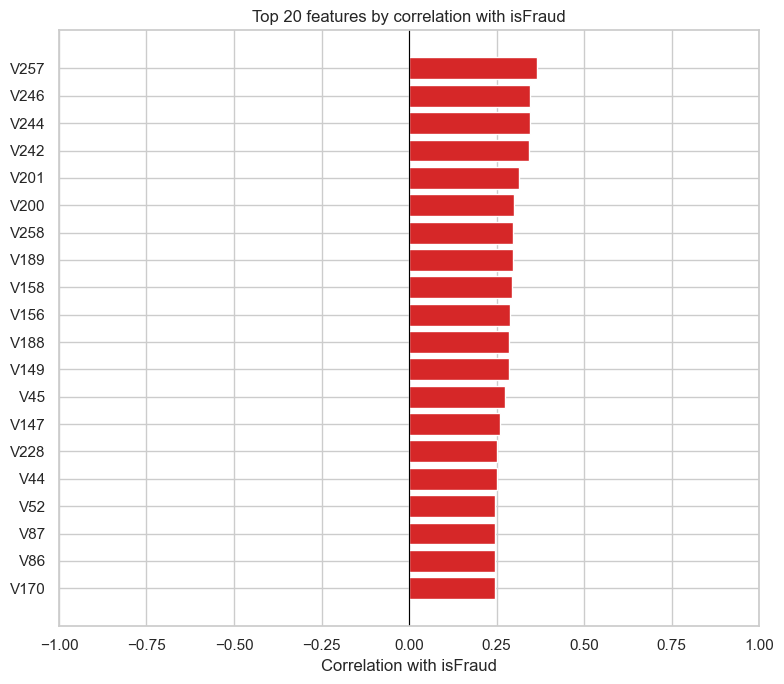

In [25]:
# Top correlations with isFraud (numeric sample for speed)
numeric_cols = train_txn.select_dtypes(include=[np.number]).columns.drop("TransactionID", errors="ignore")
sample_df = train_txn[numeric_cols].sample(n=min(100_000, len(train_txn)), random_state=SEED)
fraud_corr = sample_df.corr(numeric_only=True)["isFraud"].drop("isFraud")
corrs = fraud_corr.abs().sort_values(ascending=False)
top_corr = corrs.head(20)
print("Top 20 |correlation| with isFraud:")
display(top_corr.to_frame("abs_corr"))

fig, ax = plt.subplots(figsize=(8, 6))
heatmap_cols = top_corr.index.tolist() + ["isFraud"]
corr_matrix = sample_df[heatmap_cols].corr()
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Correlation heatmap (top 20 features + isFraud)")
plt.tight_layout()
plt.show()

top_signed = fraud_corr.reindex(top_corr.index).sort_values(key=np.abs)
fig, ax = plt.subplots(figsize=(8, 7))
colors = np.where(top_signed > 0, "#d62728", "#1f77b4")
ax.barh(top_signed.index, top_signed.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("Correlation with isFraud")
ax.set_title("Top 20 features by correlation with isFraud")
plt.tight_layout()
plt.show()

## 8. Train vs test drift


In [26]:
print("Loading test_transaction sample...")
test_txn_full = load_transaction(FILES["test_transaction"])
test_sample = test_txn_full.sample(n=min(SAMPLE_N, len(test_txn_full)), random_state=SEED)
train_sample = train_txn.sample(n=min(SAMPLE_N, len(train_txn)), random_state=SEED)

train_cols = set(train_txn.columns) - {"isFraud"}
test_cols = set(test_txn_full.columns)
print("Columns only in train:", train_cols - test_cols)
print("Columns only in test:", test_cols - train_cols)
print("Shared columns:", len(train_cols & test_cols))


Loading test_transaction sample...
Memory: 1853.9 MB -> 1088.7 MB
Columns only in train: {'txn_time', 'amt_bin', 'log_amt', 'txn_date'}
Columns only in test: set()
Shared columns: 393


**Train vs test distribution drift.** Side-by-side KDE plots (or bar proportions for `ProductCD`) for `TransactionAmt`, `TransactionDT`, and `ProductCD` on matched random samples. KS statistics printed above quantify shift; large differences suggest calibration or time-aware validation.

TransactionAmt: KS stat=0.0158, p-value=7.9940e-06
TransactionDT: KS stat=1.0000, p-value=0.0000e+00
ProductCD: KS stat=0.0269, p-value=3.7832e-16


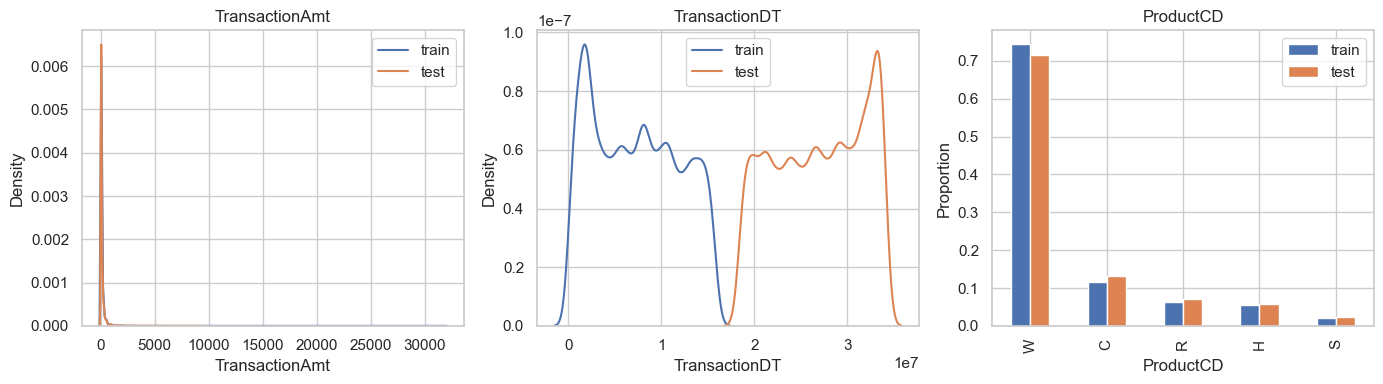

,group,n_columns_train,avg_pct_missing_train,n_columns_test,avg_pct_missing_test,missing_diff
1,D,15,58.1513,15,50.6780,-7.4733
2,M,9,49.9233,9,42.5694,-7.3539
4,V,339,43.0385,339,38.6203,-4.4182
3,email,2,46.3732,2,43.4203,-2.9530
5,addr,2,11.1264,2,12.9485,1.8221
0,other,2,76.6404,2,75.1417,-1.4987
6,card,6,0.5053,6,0.7334,0.2281
8,C,14,0.0000,14,0.0675,0.0675
7,core,5,0.0000,4,0.0000,0.0000


In [27]:
compare_cols = ["TransactionAmt", "TransactionDT", "ProductCD"]
for col in compare_cols:
    if col == "ProductCD":
        a = train_sample[col].astype(str)
        b = test_sample[col].astype(str)
    else:
        a = train_sample[col].dropna().astype(float)
        b = test_sample[col].dropna().astype(float)
    ks_stat, ks_p = stats.ks_2samp(a, b)
    print(f"{col}: KS stat={ks_stat:.4f}, p-value={ks_p:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, compare_cols):
    if col == "ProductCD":
        top = train_sample[col].value_counts().head(6).index
        prop = pd.DataFrame({
            "train": train_sample[col].value_counts(normalize=True),
            "test": test_sample[col].value_counts(normalize=True),
        }).fillna(0).loc[top]
        prop.plot(kind="bar", ax=ax)
        ax.set_ylabel("Proportion")
    else:
        sns.kdeplot(train_sample[col].dropna(), label="train", ax=ax)
        sns.kdeplot(test_sample[col].dropna(), label="test", ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

gm_train = group_missingness(train_txn, groups_txn)
test_groups = ieee_feature_groups(test_txn_full.columns)
gm_test = group_missingness(test_txn_full, test_groups)
drift_miss = gm_train.merge(gm_test, on="group", suffixes=("_train", "_test"))
drift_miss["missing_diff"] = drift_miss["avg_pct_missing_test"] - drift_miss["avg_pct_missing_train"]
display(drift_miss.sort_values("missing_diff", key=abs, ascending=False))


## 9. Duplicate and key checks


In [28]:
checks = {
    "train_txn TransactionID unique": train_txn["TransactionID"].is_unique,
    "train_id TransactionID unique": train_id["TransactionID"].is_unique,
    "merged TransactionID unique": train_merged["TransactionID"].is_unique,
    "train_id rows per TransactionID max": train_id.groupby("TransactionID").size().max(),
    "submission rows": len(pd.read_csv(FILES["sample_submission"])),
    "test_transaction rows": len(test_txn_full),
}
for k, v in checks.items():
    print(f"{k}: {v}")

sub = pd.read_csv(FILES["sample_submission"], usecols=["TransactionID"])
print("Submission IDs subset of test:", sub["TransactionID"].isin(test_txn_full["TransactionID"]).all())


train_txn TransactionID unique: True
train_id TransactionID unique: True
merged TransactionID unique: True
train_id rows per TransactionID max: 1
submission rows: 506691
test_transaction rows: 506691
Submission IDs subset of test: True


## 10. Summary


**Grain**
- **Train:** 590,540 rows × 434 columns after left-join (`train_merged`); **test:** 506,691 transactions.
- **Schemas:** `train_transaction` 394 columns; `train_identity` 41 columns; join on `TransactionID` (verified 1:1 on identity side, max 1 row per ID).
- One row per transaction; identity is optional (~76% of train rows have no identity record).

**Label**
- **20,663 fraud / 569,877 legit** → **3.50%** fraud rate; **27.6:1** legit:fraud.
- Use stratified splits, class weights, and **PR-AUC / precision@k**.

**Feature types**
- **Core:** `TransactionAmt`, `TransactionDT` (seconds from 2017-11-30), `ProductCD`.
- **ProductCD fraud rate** (n≥100): **C ~11.7%**, S ~5.9%, H ~4.8%, R ~3.8%, **W ~2.0%** (strong heterogeneity).
- **Card / addr / email:** `card1` high cardinality (~13.5k); addr/email explored via `fraud_rate_by` in section 4.
- **Blocks (transaction-only missingness):** `C*` 0% avg missing; `D*` ~58%; `M*` ~50%; `V*` ~43% (max single `V` ~86%); `C`/`D`/`M`/`V` counts: 14 / 15 / 9 / 339.
- **Identity (~24.4% coverage):** `id_01`–`id_38`, `DeviceType`, `DeviceInfo`. **Fraud rate ~7.9% with identity vs ~2.1% without** — identity presence is strongly associated with the label (not necessarily causal). **Mobile ~10.2%** vs **desktop ~6.5%** fraud rate where device is known.
- **Strongest univariate signal (100k sample):** Pearson |corr| with `isFraud` dominated by **`V*` features**; top feature **V257 ~0.37**, then V246/V244/V242 (~0.34–0.35). No single feature is a silver bullet.

**Data quality**
- **12 columns** with **>90% missing** on merged train; worst include many **`id_*`** (~99%), **`dist2`** (~94%), **`D7`** (~93%), plus **`D12`–`D14`**, **`V138`/`V139`/`V148`** (~86%).
- **Avg missing by group (merged):** `id` ~85%, `device` ~78%, `D` ~58%, `M` ~50%, `V` ~43%, `email` ~46%, `card` ~0.5%, `C`/`core` ~0%.
- Left join raises **overall avg missing** from **~40.7%** (transaction only) to **~45.1%** (merged); **identity columns ~84.5% missing** on average after join.
- **Train vs test missingness:** `D`, `M`, `V`, `email` groups slightly less missing in test (e.g. `V` avg −4.4 pp) — minor coverage drift, not column mismatch.

**Modeling implications**
- **Validation:** **Time-based split required** — `TransactionDT` KS **= 1.0** between 50k train/test samples (disjoint time periods); random splits will leak.
- **Amount / product drift:** `TransactionAmt` KS ~0.016, `ProductCD` KS ~0.027 — mild distributional shift; monitor calibration.
- **Identity:** left-join plus **missing indicators** or a separate model path; do not treat NaN identity as “safe.”
- **High-dimensional `V*`:** feature selection / regularization; expect **V–V multicollinearity** (large within-block correlations vs ~0.37 max with fraud).
- **High-missing columns:** drop or impute candidates (`id_24`, `id_25`, `dist2`, `D7`, etc.).
- **Metric:** competition **ROC-AUC**; test labels unavailable in-repo.

**Engine mapping** (`fraud_scoring_engine` Postgres schema)
- `TransactionAmt` → `transactions.amount`
- `TransactionDT` → `transactions.timestamp` (after datetime conversion)
- Identity/device signals are sparse vs IEEE (~24% coverage here); most `V*` / `C*` / `D*` columns stay in **offline ML only**, not the operational DB schema.
